In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# setting up file path for imports
import sys
import os
from pathlib import Path

cwd = Path(os.getcwd())
print(cwd)
PROJECT_ROOT = cwd.resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

# installing relevant libraries
import chaosmagpy as cp
import numpy as np
import matplotlib.pyplot as plt
import h5py

# Project paths / utilities
from src.msc_thesis.paths import *
from src.msc_thesis.synSetup import *
from src.msc_thesis.synUtils import *
from src.msc_thesis.synDMD import *

plt.rcParams.update({"font.size": 11})

/home/elliott/projects/msc_thesis_project/Last_stretch/DMD_context
['/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']
['/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']
['/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/m

In [3]:
# selecting the input modes and truncation degrees
mode_numbers = np.arange(1, 63, 1)
mode_numbers = [str(mode_number) for mode_number in mode_numbers]
nmax_values = np.arange(1, 16)

# withdrawing and storing all complex phasors
gnm_modes = []
for mode_num in mode_numbers:
    mode_info_i = Component_Load_SV(mode_num, nmax=15)
    gnm_modes.append(mode_info_i["gnm"])


In [4]:
correlation_match_metric = {
    "full_match":{},
    "partial_match":{}
}

for nmax in nmax_values:
    A_n_r = Truncate_Gauss_Coeffs(A_15_r, nmax)
    sv_n_list = [
        A_n_r @ Truncate_Gauss_Coeffs(gnm, tmax=nmax).T
        for gnm in gnm_modes
    ]

    corr_n_list = []
    for i, phasor_i_n in enumerate(sv_n_list):
        corr_n_list_sub = []

        for j, phasor_j_n in enumerate(sv_n_list):
            if i < j:
                corr_n = Complex_Phasor_Compare(
                    phasor_i_n, phasor_j_n
                )
                corr_n_list.append(corr_n)

    nmax_key = str(nmax)

    correlation_match_metric["full_match"][nmax_key] = (
        np.percentile(corr_n_list, q=97.5)
    )
    correlation_match_metric["partial_match"][nmax_key] = (
        np.percentile(corr_n_list, q=97.5)
    )

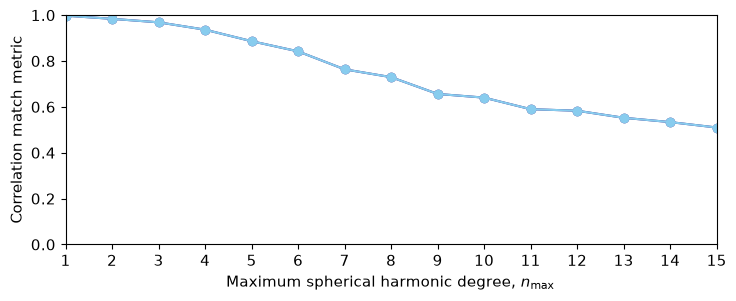

In [5]:
fig, ax = plt.subplots(
    figsize=(text_width, 0.4 * text_width), constrained_layout=True
)

mm_list_full = [correlation_match_metric["full_match"][str(nmax)] for nmax in nmax_values]
mm_list_partial = [correlation_match_metric["partial_match"][str(nmax)] for nmax in nmax_values]

ax.plot(nmax_values, mm_list_full, marker="o")
ax.plot(nmax_values, mm_list_partial, marker="o")
ax.set(
    xlabel=r"Maximum spherical harmonic degree, $n_{\max}$",
    ylabel="Correlation match metric",
    xlim=(1, 15),
    ylim=(0, 1),
    xticks=nmax_values,
)
plt.show()

In [6]:
print(mm_list_partial)

[np.float64(0.9975704899189746), np.float64(0.9838609823140836), np.float64(0.9687028815719774), np.float64(0.9365700024856844), np.float64(0.8864121501998583), np.float64(0.8419893763838422), np.float64(0.7636376465458664), np.float64(0.7295490536004132), np.float64(0.6563408400130795), np.float64(0.6402574973023905), np.float64(0.5898712588210416), np.float64(0.583124681503186), np.float64(0.5523621753065551), np.float64(0.5335353823529398), np.float64(0.5099284101994043)]


In [7]:
# save similarity metrics

felix_dir = Path(FELIX_DIR)

match_path = felix_dir / "match_metrics.pkl"

with open(match_path, "wb") as file:
    pickle.dump(correlation_match_metric, file)

print(f"Saved similarity match treshold to: {match_path}")

Saved similarity match treshold to: /home/elliott/projects/msc_thesis_project/data/modes_surface/match_metrics.pkl


In [ ]:
# basic mode i loading code - assumes SV wanted
def True_Mode_Eigenvalue(mode_number, directory=FELIX_DIR):
    # select a mode number and corresponding file
    file = h5py.File(f'{directory}/mode_surface_including_gnm_{mode_number}.h5',"r")

    # loading in true period and decay rate
    omega = file["omega"][()] # angular frequency (rad/year)
    sigma = file["sigma"][()] # annual decay rate (fractional decay/year)

    eigenvalue_decaying = sigma + 1j * omega # with decay

    file.close() # close file

    mode_i_info = {
        "mode_number": mode_number,
        "eigenvalue": eigenvalue_decaying
    }

    # returns all basic components for the mode
    return mode_i_info

periods = []
qualities = []

for mode_num in mode_numbers:
    true_eig = True_Mode_Eigenvalue(mode_num)["eigenvalue"]

    Quality = Mode_Quality_Factor(true_eig)

    periods.append(((2*np.pi)/true_eig.imag))
    qualities.append(Quality)

    

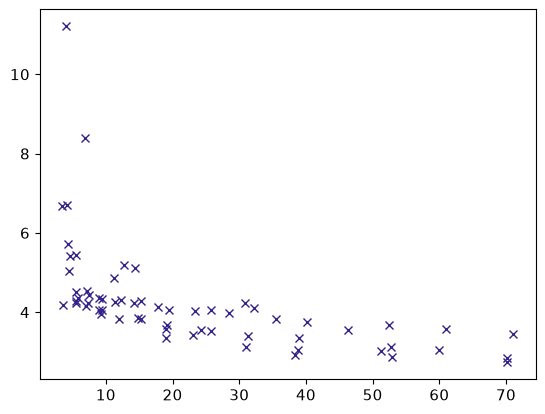

In [ ]:
plt.plot(periods, qualities, 'x')

(0.0, 100.0)

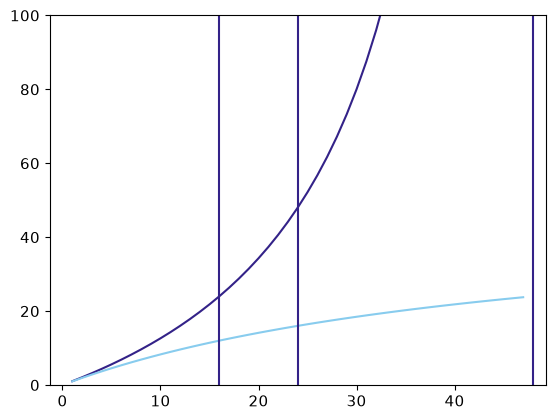

In [ ]:
# now checking fourier widths

total_time = t_dmd_end - t_dmd_start

f_width = 1/ total_time
f_hw = f_width/2

reference_periods = np.arange(1, 80, 1)
reference_f = 1/reference_periods

low_bounds = reference_f - f_hw
high_bounds = reference_f + f_hw

possible = (low_bounds > 0) & (high_bounds > 0)

plt.plot(reference_periods[possible], 1/low_bounds[possible])
plt.plot(reference_periods[possible], 1/high_bounds[possible])
plt.axvline(1/(3*f_hw))
plt.axvline(1/(2*f_hw))
plt.axvline(1/(f_hw))
plt.ylim(0, 100)